 #  Insurance Penetration and Growth Potential Analysis

### Scenario

PhonePe has entered the insurance segment and provides users
with different insurance services.

The objective is to analyze insurance transactions across
states and time periods, identify high-performing regions,
and understand growth opportunities.

####  Objective

- Identify states with the highest insurance transactions.
- Analyze insurance amount across states.
- Understand year-wise insurance growth.
- Identify regions with potential for insurance expansion.

In [4]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import numpy as np

In [6]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=DESKTOP-55JNORK\\SQLEXPRESS;"
    "DATABASE=phonepe;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

cursor = conn.cursor()

print("OK")



OK


## Load Insurance Data

In [7]:
query3 = """
select top 10 *
from aggregated_insurance
"""

df3= pd.read_sql(query3, conn)
df3

C:\Users\Devendra\AppData\Local\Temp\ipykernel_23056\1544807277.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3= pd.read_sql(query3, conn)


,States,Years,Quarter,Insurance_type,Insurance_count,Insurance_amount
0,Andaman & Nicobar,2020,2,Insurance,6,1360
1,Andaman & Nicobar,2020,3,Insurance,41,15380
2,Andaman & Nicobar,2020,4,Insurance,124,157975
3,Andaman & Nicobar,2021,1,Insurance,225,244266
4,Andaman & Nicobar,2021,2,Insurance,137,181504
5,Andaman & Nicobar,2021,3,Insurance,230,305235
6,Andaman & Nicobar,2021,4,Insurance,757,1056380
7,Andaman & Nicobar,2022,1,Insurance,768,1131287
8,Andaman & Nicobar,2022,2,Insurance,501,779740
9,Andaman & Nicobar,2022,3,Insurance,643,902466


### Insurance Type Analysis

In [9]:
query = """
select
Insurance_type,
sum(Insurance_count) as Total_Transactions,
sum(Insurance_amount) as Total_Amount
from aggregated_insurance
group by Insurance_type 
order by Total_Amount Desc"""


insurance_type = pd.read_sql(query, conn)

insurance_type

C:\Users\Devendra\AppData\Local\Temp\ipykernel_23056\558983879.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  insurance_type = pd.read_sql(query, conn)


,Insurance_type,Total_Transactions,Total_Amount
0,Insurance,29031374,40031156768


## Chart

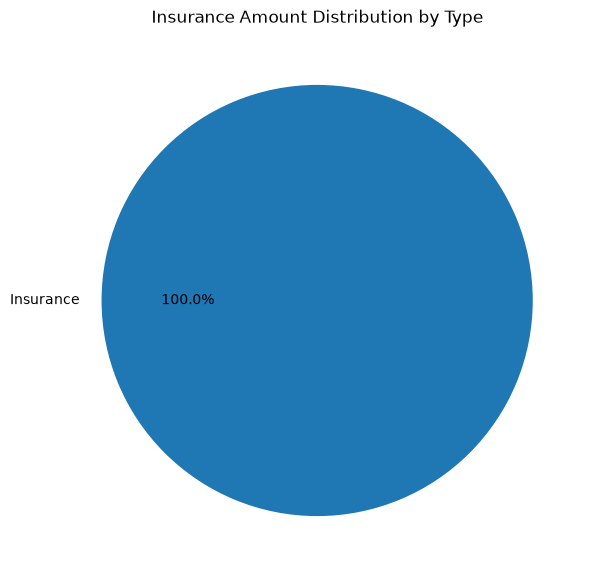

In [11]:
plt.figure(figsize=(7,7))

plt.pie(
    insurance_type["Total_Amount"],
    labels=insurance_type["Insurance_type"],
    autopct="%1.1f%%"
)

plt.title("Insurance Amount Distribution by Type")
plt.show()

In [12]:
df3["Insurance_type"].unique()

<ArrowStringArray>
['Insurance']
Length: 1, dtype: str

## Top 10 States

In [20]:
query = """
SELECT TOP 10
    States,
    SUM(Insurance_amount) AS Total_Amount
FROM aggregated_insurance
GROUP BY States
ORDER BY Total_Amount DESC
"""

insurance_states = pd.read_sql(query, conn)

insurance_states

C:\Users\Devendra\AppData\Local\Temp\ipykernel_23056\1156893556.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  insurance_states = pd.read_sql(query, conn)


,States,Total_Amount
0,Karnataka,5486309694
1,Maharashtra,4726257072
2,Uttar Pradesh,3480692990
3,Tamil Nadu,3111014506
4,Kerala,2627437014
5,Telangana,2342119030
6,West Bengal,2104926478
7,Rajasthan,1919307720
8,Haryana,1661962454
9,Delhi,1630730344


## Bar Chart

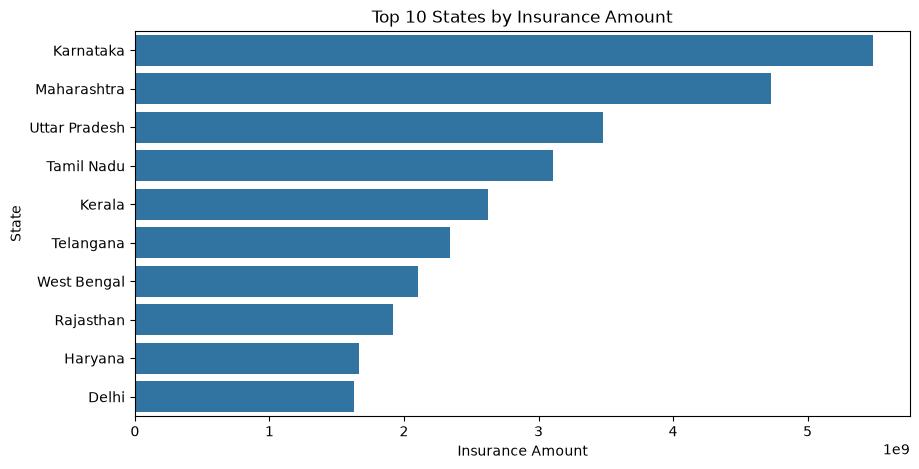

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=insurance_states,
    x="Total_Amount",
    y="States"
)

plt.title("Top 10 States by Insurance Amount")
plt.xlabel("Insurance Amount")
plt.ylabel("State")

plt.show()

In [17]:
insurance_states.columns

Index(['Insurance_type', 'Total_Transactions', 'Total_Amount'], dtype='str')

 #### Conclusion

The analysis identifies the leading insurance categories and
top-performing states based on insurance transaction value.

These insights can help PhonePe identify high-performing
regions and target potential areas for insurance expansion
and marketing activities.